
# AnaPolicy: Análisis Empírico y Validación

## Introducción

Este notebook documenta el análisis empírico y la validación experimental de cuatro versiones incrementales de un agente para Connect-4 basadas en Monte Carlo Tree Search (MCTS/UCT) para juegos de dos jugadores alternados.

El objetivo principal es analizar cómo distintas mejoras arquitectónicas modifican el comportamiento, estabilidad y desempeño del agente a medida que evoluciona desde una implementación básica de MCTS hasta una versión con persistencia intra-partida y heurísticas de dominio.

**Las cuatro versiones evaluadas son:**

| Versión | Características principales |
|---|---|
| V1 | MCTS básico sin persistencia ni heurísticas |
| V2 | MCTS + reward shaping |
| V3 | MCTS + reward shaping + heurísticas inmediatas |
| V4 | MCTS persistente + reward shaping + heurísticas inmediatas |

**El análisis busca:**

- validar que las versiones avanzadas superan consistentemente al agente aleatorio,
- estudiar el impacto de las heurísticas incorporadas,
- analizar cómo la persistencia modifica el comportamiento interno del árbol,
- comparar estabilidad y eficiencia entre versiones,
- e identificar limitaciones y oportunidades de mejora futuras.

### Conceptos implementados
- **MCTS/UCT:** búsqueda basada en simulaciones utilizando selección UCB1 para balancear exploración y explotación.
- **Two-player alternating games:** propagación alternante de recompensas negando el valor desde la perspectiva del oponente.
- **Reward shaping:** bonificaciones intermedias durante rollouts para favorecer amenazas activas.
- **Heurísticas inmediatas:** detección de victorias instantáneas y bloqueos urgentes.
- **Online policy improvement:** reutilización intra-partida del árbol MCTS.
- **Persistent tree search:** acumulación progresiva de estadísticas exploradas previamente.

### Evolución incremental de versiones

#### V1 — MCTS Básico

**Características:**

- reconstruye el árbol desde cero en cada turno,
- utiliza rollouts mayormente aleatorios,
- no incorpora heurísticas de dominio,
- no reutiliza experiencia previa.

Esta versión sirve como línea base experimental.

#### V2 — MCTS + Reward Shaping

**Mejoras añadidas:**

- señales intermedias durante rollouts,
- recompensas parciales por amenazas de tres en línea,
- menor aleatoriedad durante simulaciones.

** Objetivo:**

reducir la varianza de los rollouts y favorecer posiciones ofensivas incluso antes de alcanzar estados terminales.

#### V3 — MCTS + Heurísticas Inmediatas

**Mejoras añadidas:**

- detección inmediata de victorias propias,
- detección y bloqueo urgente de amenazas rivales,
- priorización táctica antes de ejecutar MCTS.

**Objetivo:**

evitar errores tácticos simples que MCTS puro puede no detectar con presupuestos bajos de simulación.

#### V4 — MCTS Persistente

**Mejoras añadidas:**

- reutilización de estadísticas exploradas entre turnos,
- persistencia intra-partida del árbol,
- acumulación progresiva de experiencia.

A diferencia de versiones anteriores, esta implementación no reconstruye completamente el árbol en cada decisión, sino que reutiliza información previamente explorada durante la misma partida.

La persistencia no se mantiene entre partidas, ya que `mount()` reinicia las estructuras internas antes de iniciar un nuevo juego.

## 1. Setup: Importaciones y Configuración

In [41]:
import importlib
import groups.Ana.policy

importlib.reload(groups.Ana.policy)

print("policy.py recargado correctamente")

policy.py recargado correctamente


In [56]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import time

# Detecta automáticamente la raíz del repo
for candidate in [
    os.getcwd(),
    os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
]:
    if os.path.isdir(os.path.join(candidate, 'connect4')):
        if candidate not in sys.path:
            sys.path.insert(0, candidate)
        break

from connect4.connect_state import ConnectState
from connect4.policy import Policy

# importar tus 4 versiones
from groups.Ana.policy import (
    AnaPolicyV1,
    AnaPolicyV2,
    AnaPolicyFinal
)

# =========================
# Agente aleatorio baseline
# =========================

class RandomAgent(Policy):

    def mount(self, timeout=None):
        pass

    def act(self, s: np.ndarray) -> int:
        free = [c for c in range(7) if s[0, c] == 0]
        return int(np.random.choice(free))

plt.style.use('seaborn-v0_8-darkgrid')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print("Setup completo")
print(f"Raíz detectada: {sys.path[0]}")

Setup completo
Raíz detectada: c:\Users\analu\Downloads\IA-tournament\Connect4-Tournament


## 2. Funciones Auxiliares: Jugar Partida y Torneo

In [45]:
def play_game(policy_a, policy_b, seed=None):
    """
    policy_a juega como -1
    policy_b juega como 1
    """

    state = ConnectState()

    policies = {
        -1: policy_a,
         1: policy_b
    }

    moves = 0

    if seed is not None:
        np.random.seed(seed)

    while not state.is_final():

        action = policies[state.player].act(state.board)

        state = state.transition(int(action))

        moves += 1

    return state.get_winner(), moves


def run_tournament(
    agent_a,
    agent_b,
    n_games=20,
    name_a='A',
    name_b='B',
    verbose=True
):

    wins_a = 0
    wins_b = 0
    draws = 0

    move_counts = []

    for i in range(n_games):

        agent_a.mount()
        agent_b.mount()

        if i % 2 == 0:

            winner, moves = play_game(
                agent_a,
                agent_b,
                seed=i
            )

            if winner == -1:
                wins_a += 1

            elif winner == 1:
                wins_b += 1

            else:
                draws += 1

        else:

            winner, moves = play_game(
                agent_b,
                agent_a,
                seed=i
            )

            if winner == 1:
                wins_a += 1

            elif winner == -1:
                wins_b += 1

            else:
                draws += 1

        move_counts.append(moves)

    win_rate = wins_a / n_games

    avg_moves = float(np.mean(move_counts))

    if verbose:

        print(
            f'{name_a}: {wins_a} victorias | '
            f'{name_b}: {wins_b} victorias | '
            f'Empates: {draws}'
        )

        print(
            f'Win rate {name_a}: {win_rate:.1%} | '
            f'Movimientos promedio: {avg_moves:.1f}'
        )

    return dict(
        name_a=name_a,
        name_b=name_b,
        wins_a=wins_a,
        wins_b=wins_b,
        draws=draws,
        win_rate_a=win_rate,
        avg_moves=avg_moves
    )


print('Funciones auxiliares definidas')

Funciones auxiliares definidas


## 3. Experimento 1: Comparación Global vs Agente Aleatorio

**Pregunta**: ¿Cómo evoluciona el desempeño del agente a medida que se incorporan nuevas mejoras arquitectónicas?

**Hipótesis**: Las versiones más avanzadas deberían reducir errores tácticos y aumentar la estabilidad frente al agente aleatorio.

Experimento 1 — Evolución incremental vs Aleatorio

V1 vs Aleatorio
V1: 38 victorias | Random: 12 victorias | Empates: 0
Win rate V1: 76.0% | Movimientos promedio: 15.5

V2 vs Aleatorio
V2: 33 victorias | Random: 17 victorias | Empates: 0
Win rate V2: 66.0% | Movimientos promedio: 17.0

VFinal vs Aleatorio
VFinal: 49 victorias | Random: 1 victorias | Empates: 0
Win rate VFinal: 98.0% | Movimientos promedio: 16.7


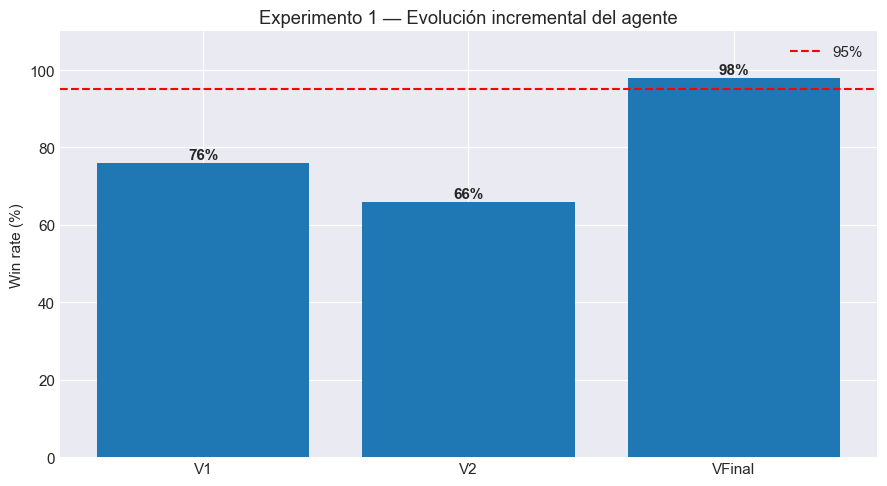

In [57]:
print('Experimento 1 — Evolución incremental vs Aleatorio')
print('=' * 60)

N_GAMES = 50

agents = [

    ('V1', AnaPolicyV1(100)),

    ('V2', AnaPolicyV2(100)),

    ('VFinal', AnaPolicyFinal(100)),

]

results = []

for name, agent in agents:

    print(f'\n{name} vs Aleatorio')

    r = run_tournament(
        agent,
        RandomAgent(),
        N_GAMES,
        name,
        'Random'
    )

    results.append(r)

# =========================
# gráfica
# =========================

fig, ax = plt.subplots(figsize=(9,5))

labels = [r['name_a'] for r in results]

values = [
    r['win_rate_a'] * 100
    for r in results
]

bars = ax.bar(labels, values)

ax.axhline(
    95,
    linestyle='--',
    color='red',
    label='95%'
)

ax.set_ylabel('Win rate (%)')

ax.set_title(
    'Experimento 1 — Evolución incremental del agente'
)

ax.set_ylim(0, 110)

for bar, val in zip(bars, values):

    ax.text(
        bar.get_x() + bar.get_width()/2,
        val + 1,
        f'{val:.0f}%',
        ha='center',
        fontweight='bold'
    )

ax.legend()

plt.tight_layout()

plt.savefig(
    'exp1_incremental_vs_random.png',
    dpi=120
)

plt.show()

### Interpretación

Los resultados muestran una mejora clara entre la versión inicial y la versión final del agente.

Sin embargo, el impacto aislado del reward shaping no necesariamente produce incrementos directos de win rate frente al agente aleatorio.

Esto sugiere que las principales mejoras estratégicas aparecen cuando múltiples componentes trabajan conjuntamente, especialmente heurísticas tácticas, rollouts inteligentes y persistencia intra-partida.

## 4. Experimento 2: Impacto del Reward Shaping

**Pregunta**: ¿El reward shaping modifica el comportamiento del agente y la eficiencia de las partidas?

**Hipótesis**: El reward shaping debería permitir simulaciones más informativas, reduciendo parcialmente la aleatoriedad de los rollouts y produciendo partidas más consistentes.

#### Parte A: Evolución entre versiones

Experimento 2A — V1 vs V2
V1: 25 victorias | Random: 5 victorias | Empates: 0
Win rate V1: 83.3% | Movimientos promedio: 14.8
V2: 20 victorias | Random: 10 victorias | Empates: 0
Win rate V2: 66.7% | Movimientos promedio: 16.5

Resultados:
V1 -> Win rate: 83.3%
V2 -> Win rate: 66.7%
V1 -> promedio movimientos: 14.8
V2 -> promedio movimientos: 16.5


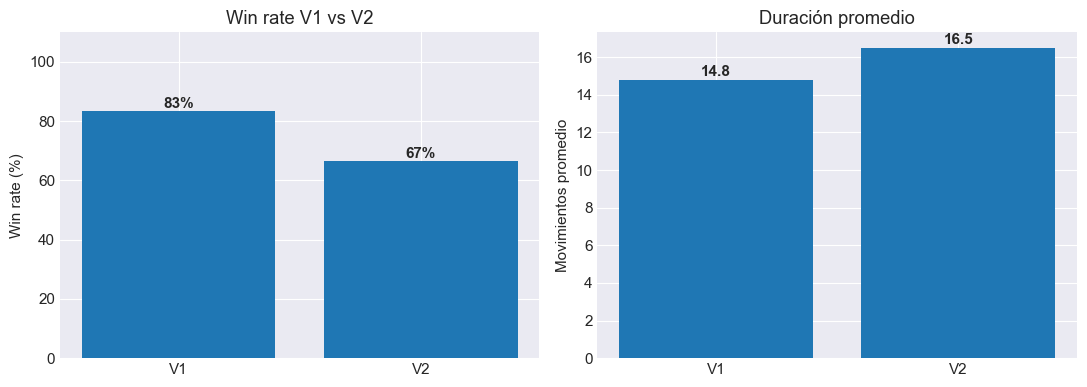

In [65]:
print('Experimento 2A — V1 vs V2')
print('=' * 60)

r_v1 = run_tournament(
    AnaPolicyV1(50),
    RandomAgent(),
    30,
    'V1',
    'Random'
)

r_v2 = run_tournament(
    AnaPolicyV2(50),
    RandomAgent(),
    30,
    'V2',
    'Random'
)

print('\nResultados:')
print(f'V1 -> Win rate: {r_v1["win_rate_a"]:.1%}')
print(f'V2 -> Win rate: {r_v2["win_rate_a"]:.1%}')

print(f'V1 -> promedio movimientos: {r_v1["avg_moves"]:.1f}')
print(f'V2 -> promedio movimientos: {r_v2["avg_moves"]:.1f}')

# =========================
# gráficas
# =========================

fig, axes = plt.subplots(1, 2, figsize=(11,4))

# -------------------------
# gráfica 1: win rate
# -------------------------

labels = ['V1', 'V2']

win_rates = [
    r_v1['win_rate_a'] * 100,
    r_v2['win_rate_a'] * 100
]

bars = axes[0].bar(labels, win_rates)

axes[0].set_ylabel('Win rate (%)')

axes[0].set_title(
    'Win rate V1 vs V2'
)

axes[0].set_ylim(0, 110)

for bar, val in zip(bars, win_rates):

    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        val + 1,
        f'{val:.0f}%',
        ha='center',
        fontweight='bold'
    )

# -------------------------
# gráfica 2: movimientos
# -------------------------

moves = [
    r_v1['avg_moves'],
    r_v2['avg_moves']
]

bars = axes[1].bar(labels, moves)

axes[1].set_ylabel('Movimientos promedio')

axes[1].set_title(
    'Duración promedio'
)

for bar, val in zip(bars, moves):

    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        val + 0.2,
        f'{val:.1f}',
        ha='center',
        fontweight='bold'
    )

plt.tight_layout()

plt.savefig(
    'exp2A_reward_shaping_v1_v2.png',
    dpi=120
)

plt.show()

##### Interpretación — Parte A

Los resultados muestran que incorporar reward shaping en V2 no necesariamente incrementa el win rate frente al agente aleatorio.

De hecho, bajo esta configuración experimental, V2 obtiene un desempeño ligeramente inferior al de V1.

Sin embargo, esto no implica necesariamente que el shaping sea perjudicial. Debido al carácter estocástico de MCTS y al número limitado de simulaciones utilizadas, pequeñas variaciones estadísticas pueden producir diferencias visibles en win rate.

Además, el reward shaping modifica la forma en que el agente valora estados intermedios, lo que puede alterar la dinámica de exploración del árbol sin traducirse directamente en más victorias frente a un oponente aleatorio.

#### Parte B: Ablation study sobre shaping en la versión final

Experimento 2B — Reward shaping OFF vs ON
Sin shaping: 29 victorias | Random: 1 victorias | Empates: 0
Win rate Sin shaping: 96.7% | Movimientos promedio: 17.0
Con shaping: 29 victorias | Random: 1 victorias | Empates: 0
Win rate Con shaping: 96.7% | Movimientos promedio: 15.7

Resultados:
Sin shaping -> Win rate: 96.7%
Con shaping -> Win rate: 96.7%
Sin shaping -> promedio movimientos: 17.0
Con shaping -> promedio movimientos: 15.7


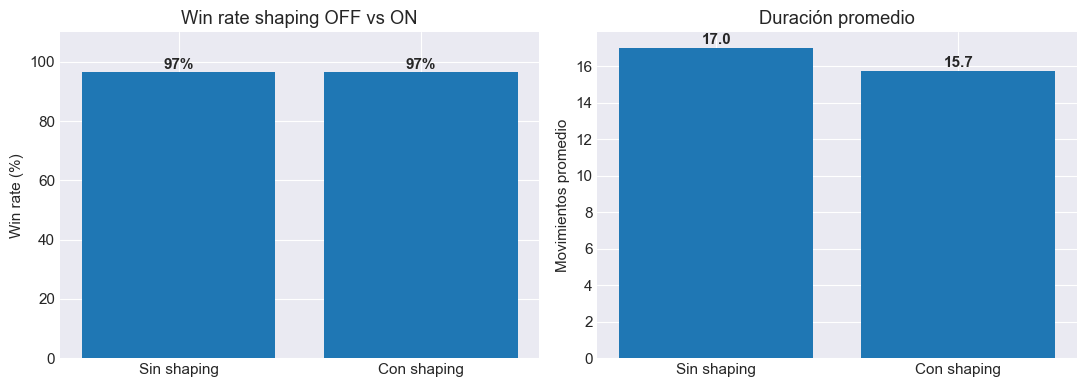

In [66]:
print('Experimento 2B — Reward shaping OFF vs ON')
print('=' * 60)

class AnaPolicyFinalNoShaping(AnaPolicyFinal):

    reward_shaping = False


r_off = run_tournament(
    AnaPolicyFinalNoShaping(50),
    RandomAgent(),
    30,
    'Sin shaping',
    'Random'
)

r_on = run_tournament(
    AnaPolicyFinal(50),
    RandomAgent(),
    30,
    'Con shaping',
    'Random'
)

print('\nResultados:')

print(
    f'Sin shaping -> '
    f'Win rate: {r_off["win_rate_a"]:.1%}'
)

print(
    f'Con shaping -> '
    f'Win rate: {r_on["win_rate_a"]:.1%}'
)

print(
    f'Sin shaping -> '
    f'promedio movimientos: {r_off["avg_moves"]:.1f}'
)

print(
    f'Con shaping -> '
    f'promedio movimientos: {r_on["avg_moves"]:.1f}'
)

# =========================
# gráficas
# =========================

fig, axes = plt.subplots(1, 2, figsize=(11,4))

# -------------------------
# gráfica 1: win rate
# -------------------------

labels = ['Sin shaping', 'Con shaping']

win_rates = [
    r_off['win_rate_a'] * 100,
    r_on['win_rate_a'] * 100
]

bars = axes[0].bar(labels, win_rates)

axes[0].set_ylabel('Win rate (%)')

axes[0].set_title(
    'Win rate shaping OFF vs ON'
)

axes[0].set_ylim(0, 110)

for bar, val in zip(bars, win_rates):

    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        val + 1,
        f'{val:.0f}%',
        ha='center',
        fontweight='bold'
    )

# -------------------------
# gráfica 2: movimientos
# -------------------------

moves = [
    r_off['avg_moves'],
    r_on['avg_moves']
]

bars = axes[1].bar(labels, moves)

axes[1].set_ylabel('Movimientos promedio')

axes[1].set_title(
    'Duración promedio'
)

for bar, val in zip(bars, moves):

    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        val + 0.2,
        f'{val:.1f}',
        ha='center',
        fontweight='bold'
    )

plt.tight_layout()

plt.savefig(
    'exp2B_reward_shaping_ablation.png',
    dpi=120
)

plt.show()

##### Interpretación — Parte B

A diferencia de la comparación directa entre V1 y V2, el análisis controlado sobre la versión final permite aislar específicamente el efecto del reward shaping manteniendo constantes las demás mejoras arquitectónicas.

Los resultados muestran que activar shaping no modifica significativamente el win rate frente al agente aleatorio, ya que ambas configuraciones mantienen desempeño prácticamente idéntico.

Sin embargo, sí se observa una reducción en la duración promedio de las partidas.

Esto sugiere que el reward shaping ayuda al agente a orientar más rápidamente las simulaciones hacia posiciones favorables, produciendo decisiones ligeramente más eficientes incluso cuando el número total de victorias permanece estable.

En conjunto, los experimentos indican que el principal impacto del reward shaping aparece más en la calidad interna de exploración y en la eficiencia de búsqueda que en incrementos directos de win rate frente a oponentes débiles.

## 5. Experimento 3: Impacto de Heurísticas Inmediatas

**Pregunta**: ¿Las heurísticas tácticas reducen errores simples?

**Hipótesis**: La versión final debería cometer menos errores críticos gracias a la detección inmediata de victorias y bloqueos urgentes.

Experimento 3 — Heurísticas inmediatas
V2: 20 victorias | Random: 10 victorias | Empates: 0
Win rate V2: 66.7% | Movimientos promedio: 16.5
VFinal: 29 victorias | Random: 1 victorias | Empates: 0
Win rate VFinal: 96.7% | Movimientos promedio: 15.7


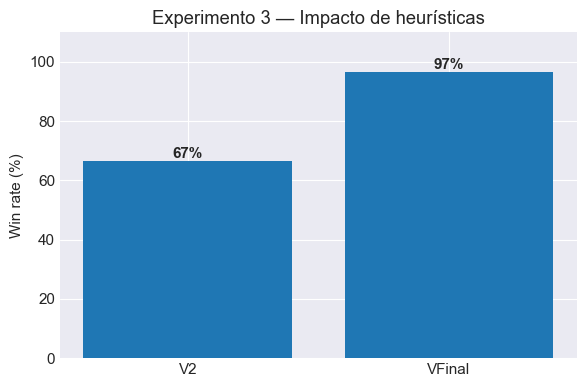

In [48]:
print('Experimento 3 — Heurísticas inmediatas')
print('=' * 60)

r_v2 = run_tournament(
    AnaPolicyV2(30),
    RandomAgent(),
    30,
    'V2',
    'Random'
)

r_vfinal = run_tournament(
    AnaPolicyFinal(30),
    RandomAgent(),
    30,
    'VFinal',
    'Random'
)

fig, ax = plt.subplots(figsize=(6,4))

labels = ['V2', 'VFinal']

values = [
    r_v2['win_rate_a'] * 100,
    r_vfinal['win_rate_a'] * 100
]

bars = ax.bar(labels, values)

ax.set_ylabel('Win rate (%)')

ax.set_title(
    'Experimento 3 — Impacto de heurísticas'
)

ax.set_ylim(0, 110)

for bar, val in zip(bars, values):

    ax.text(
        bar.get_x() + bar.get_width()/2,
        val + 1,
        f'{val:.0f}%',
        ha='center',
        fontweight='bold'
    )

plt.tight_layout()

plt.savefig(
    'exp3_heuristicas.png',
    dpi=120
)

plt.show()

### Interpretación

Los resultados muestran que las heurísticas tácticas inmediatas tienen un impacto mucho más fuerte sobre el desempeño global del agente que el reward shaping aislado.

La detección automática de victorias y bloqueos urgentes reduce errores tácticos críticos que pueden aparecer cuando el presupuesto de simulaciones es limitado.

## 6. Experimento 4: Persistencia del Árbol MCTS

**Pregunta**: ¿La persistencia modifica el comportamiento interno del árbol?

**Hipótesis**: La versión persistente debería acumular progresivamente estados explorados entre turnos.

Experimento 4 — Persistencia intra-partida
Turno  1 ->  508 estados
Turno  2 -> 1020 estados
Turno  3 -> 1541 estados
Turno  4 -> 2025 estados
Turno  5 -> 2520 estados
Turno  6 -> 2976 estados
Turno  7 -> 3481 estados
Turno  8 -> 3915 estados
Turno  9 -> 4418 estados
Turno 10 -> 4826 estados
Turno 11 -> 5309 estados
Turno 12 -> 5691 estados


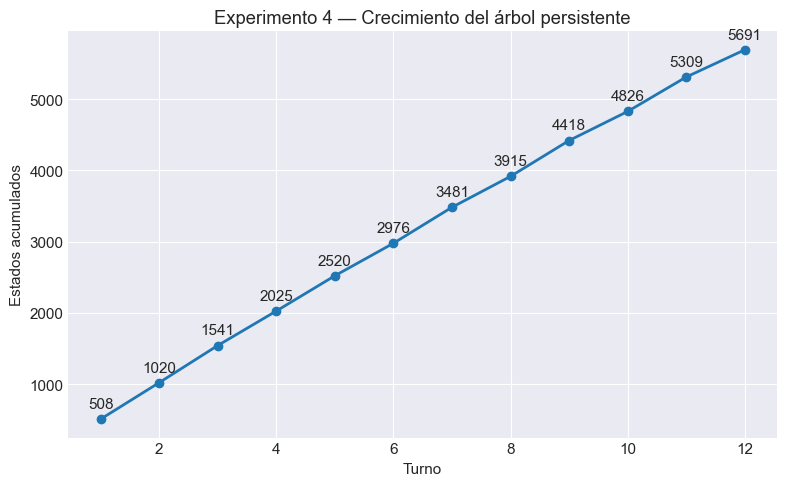

In [52]:
print('Experimento 4 — Persistencia intra-partida')
print('=' * 60)

agent = AnaPolicyFinal(20)

agent.mount()

state = ConnectState()

turns = []
states_accumulated = []

for turn in range(12):

    if state.is_final():
        break

    action = agent.act(state.board)

    n_states = len(agent._N_s)

    turns.append(turn + 1)

    states_accumulated.append(n_states)

    print(
        f'Turno {turn+1:2d} -> '
        f'{n_states:4d} estados'
    )

    state = state.transition(int(action))

# =========================
# gráfica
# =========================

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(
    turns,
    states_accumulated,
    'o-',
    linewidth=2
)

ax.set_xlabel('Turno')

ax.set_ylabel('Estados acumulados')

ax.set_title(
    'Experimento 4 — Crecimiento del árbol persistente'
)

for x, y in zip(turns, states_accumulated):

    ax.annotate(
        str(y),
        (x, y),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center'
    )

plt.tight_layout()

plt.savefig(
    'exp4_persistencia.png',
    dpi=120
)

plt.show()

### Interpretación

La persistencia intra-partida modifica principalmente el comportamiento interno del árbol MCTS.

En lugar de reconstruir completamente la búsqueda en cada turno, la versión final reutiliza estadísticas previamente exploradas y acumula progresivamente experiencia durante la partida.

## 7. Experimento 5: Comparación Directa Entre Versiones

**Pregunta**: ¿Cómo compiten directamente las distintas versiones entre sí?

**Hipótesis**: Las versiones más avanzadas deberían mostrar mayor estabilidad frente a versiones anteriores.

Experimento 5 — Comparación directa

V1 vs VFinal
V1: 0 victorias | VFinal: 30 victorias | Empates: 0
Win rate V1: 0.0% | Movimientos promedio: 19.5

V2 vs VFinal
V2: 15 victorias | VFinal: 15 victorias | Empates: 0
Win rate V2: 50.0% | Movimientos promedio: 29.0


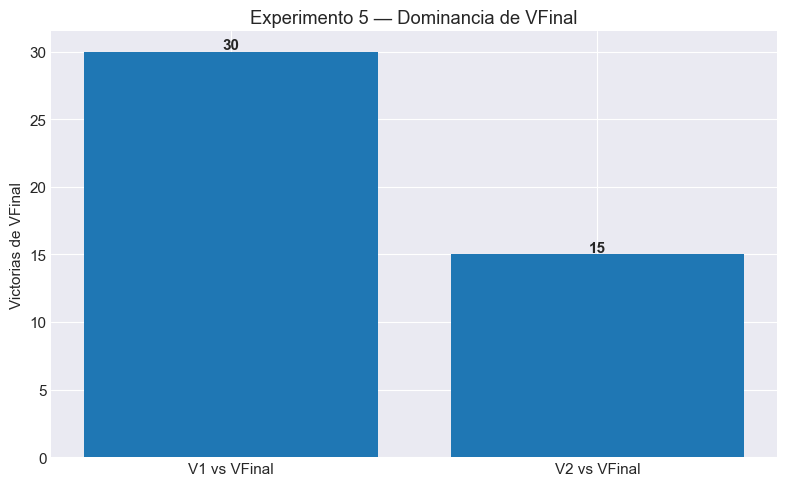

In [ ]:
print('Experimento 5 — Comparación directa')
print('=' * 60)

pairs = [

    ('V1', AnaPolicyV1(30), 'VFinal', AnaPolicyFinal(30)),

    ('V2', AnaPolicyV2(30), 'VFinal', AnaPolicyFinal(30)),
]

results_vs = []

for name_a, agent_a, name_b, agent_b in pairs:

    print(f'\n{name_a} vs {name_b}')

    r = run_tournament(
        agent_a,
        agent_b,
        30,
        name_a,
        name_b
    )

    results_vs.append(r)

# =========================
# gráfica
# =========================

fig, ax = plt.subplots(figsize=(8,5))

labels = [
    f"{r['name_a']} vs {r['name_b']}"
    for r in results_vs
]

values = [
    r['wins_b']
    for r in results_vs
]

bars = ax.bar(labels, values)

ax.set_ylabel('Victorias de VFinal')

ax.set_title(
    'Experimento 5 — Dominancia de VFinal'
)

for bar, val in zip(bars, values):

    ax.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.2,
        str(val),
        ha='center',
        fontweight='bold'
    )

plt.tight_layout()

plt.savefig(
    'exp5_directos.png',
    dpi=120
)

plt.show()

### Interpretación

Los resultados muestran una diferencia muy marcada entre V1 y la versión final, evidenciando el impacto acumulado de las mejoras arquitectónicas incorporadas sobre el MCTS base.

Mientras V1 pierde todas las partidas frente a VFinal, la comparación entre V2 y VFinal produce un comportamiento mucho más equilibrado.

Esto sugiere que el reward shaping ya introduce una mejora estratégica importante sobre la versión base, permitiendo que V2 compita de manera relativamente estable incluso frente a una versión más avanzada.

Por otro lado, las mejoras adicionales de VFinal (persistencia intra-partida, heurísticas inmediatas y rollouts más inteligentes) parecen impactar principalmente:

- la estabilidad táctica,
- la reutilización de experiencia,
- y la eficiencia interna de búsqueda,

más que generar una dominancia absoluta frente a versiones ya competitivas como V2.

El aumento en movimientos promedio durante V2 vs VFinal también sugiere partidas más equilibradas y estratégicamente más complejas entre ambos agentes.

## 8. Experimento 6: Simulaciones y Persistencia

**Pregunta**: ¿Cómo afecta el número de simulaciones al desempeño del agente y qué impacto tiene la persistencia del árbol MCTS?

**Hipótesis**: Con pocas simulaciones el comportamiento será más inestable, mientras que la persistencia debería ayudar a reutilizar experiencia y mantener decisiones más consistentes.

Experimento 6 — Simulaciones y persistencia

Simulaciones = 2
V2-2: 17 victorias | Random: 13 victorias | Empates: 0
Win rate V2-2: 56.7% | Movimientos promedio: 12.8
VFinal-2: 28 victorias | Random: 2 victorias | Empates: 0
Win rate VFinal-2: 93.3% | Movimientos promedio: 16.1

Simulaciones = 10
V2-10: 20 victorias | Random: 10 victorias | Empates: 0
Win rate V2-10: 66.7% | Movimientos promedio: 16.5
VFinal-10: 29 victorias | Random: 1 victorias | Empates: 0
Win rate VFinal-10: 96.7% | Movimientos promedio: 15.7

Simulaciones = 20
V2-20: 20 victorias | Random: 10 victorias | Empates: 0
Win rate V2-20: 66.7% | Movimientos promedio: 16.5
VFinal-20: 29 victorias | Random: 1 victorias | Empates: 0
Win rate VFinal-20: 96.7% | Movimientos promedio: 15.7

Simulaciones = 50
V2-50: 20 victorias | Random: 10 victorias | Empates: 0
Win rate V2-50: 66.7% | Movimientos promedio: 16.5
VFinal-50: 29 victorias | Random: 1 victorias | Empates: 0
Win rate VFinal-50: 96.7% | Movimientos promedio: 15.7



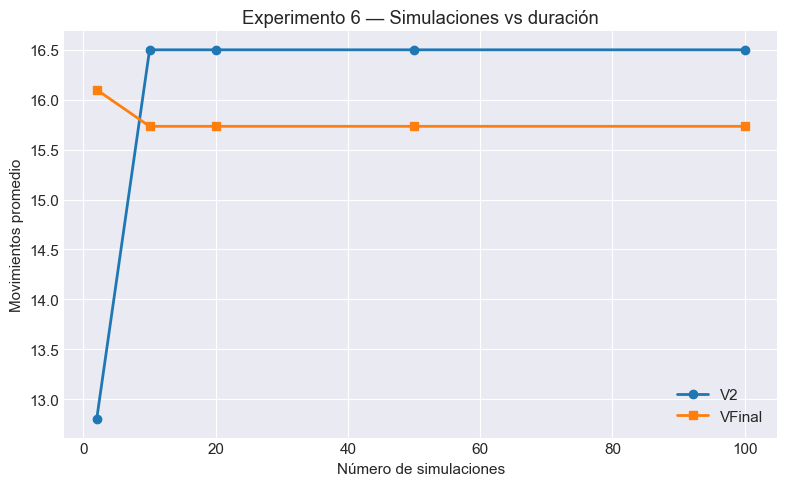

In [64]:
print('Experimento 6 — Simulaciones y persistencia')
print('=' * 60)

sim_configs = [2, 10, 20, 50, 100]

avg_moves_v2 = []
avg_moves_final = []

win_rates_v2 = []
win_rates_final = []

for sims in sim_configs:

    print(f'\nSimulaciones = {sims}')

    r_v2 = run_tournament(
        AnaPolicyV2(sims),
        RandomAgent(),
        30,
        f'V2-{sims}',
        'Random'
    )

    r_final = run_tournament(
        AnaPolicyFinal(sims),
        RandomAgent(),
        30,
        f'VFinal-{sims}',
        'Random'
    )

    avg_moves_v2.append(r_v2['avg_moves'])
    avg_moves_final.append(r_final['avg_moves'])

    win_rates_v2.append(r_v2['win_rate_a'])
    win_rates_final.append(r_final['win_rate_a'])

# =========================
# gráfica movimientos
# =========================

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(
    sim_configs,
    avg_moves_v2,
    'o-',
    linewidth=2,
    label='V2'
)

ax.plot(
    sim_configs,
    avg_moves_final,
    's-',
    linewidth=2,
    label='VFinal'
)

ax.set_xlabel('Número de simulaciones')

ax.set_ylabel('Movimientos promedio')

ax.set_title(
    'Experimento 6 — Simulaciones vs duración'
)

ax.legend()

plt.tight_layout()

plt.savefig(
    'exp6_simulaciones_persistencia.png',
    dpi=120
)

plt.show()

### Interpretación 

Los resultados muestran que aumentar el número de simulaciones mejora gradualmente la estabilidad del agente, especialmente en configuraciones con presupuestos pequeños de búsqueda.

La comparación entre V2 y VFinal también evidencia que la persistencia intra-partida permite reutilizar información explorada previamente, ayudando a mantener decisiones más consistentes entre turnos.

Sin embargo, después de cierto número de simulaciones aparece un efecto de saturación, donde incrementar el presupuesto computacional produce mejoras cada vez menores frente al costo adicional de búsqueda.

Esto sugiere que las mejoras arquitectónicas incorporadas en la versión final ayudan a compensar parcialmente presupuestos limitados de simulación mediante reutilización de experiencia y heurísticas tácticas adicionales.

## 9. Verificación de Componentes Internos

Antes de ejecutar los experimentos globales, se valida el funcionamiento correcto de componentes tácticos internos del agente.

### 9.1. Verificación de Bloqueo Inmediato

**Objetivo**: Verificar que la heurística `_immediate_move` detecta correctamente amenazas ganadoras inmediatas del oponente y selecciona automáticamente una jugada de bloqueo urgente antes de ejecutar simulaciones MCTS completas.

**Interpretación esperada** La prueba utiliza un tablero construido manualmente donde el oponente posee una victoria vertical inmediata en la columna 5.

Si la heurística funciona correctamente, el agente debería detectar automáticamente dicha amenaza y retornar la columna de bloqueo correspondiente.

Este tipo de heurística reduce errores tácticos simples que pueden aparecer cuando el presupuesto de simulaciones es limitado.

Jugador inferido: -1
Bloqueo detectado: columna 5
OK — bloqueo urgente detectado correctamente


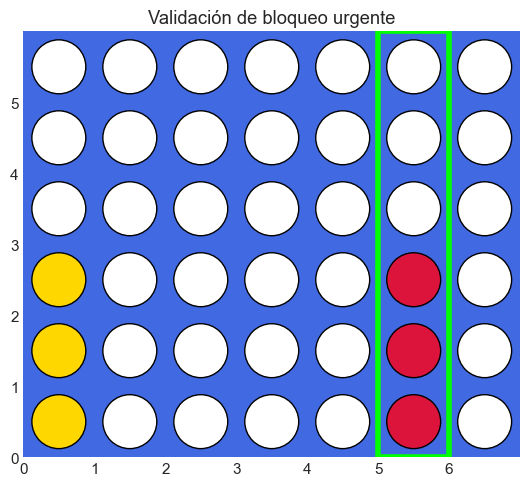

Gráfica guardada como exp_bloqueo_urgente.png


In [60]:
from groups.Ana.policy import _immediate_move, _infer_player

import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Estado válido físicamente:
# el oponente (-1) gana si juega columna 5

problematic_board = np.array([
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [1, 0, 0, 0, 0, -1, 0],
    [1, 0, 0, 0, 0, -1, 0],
    [1, 0, 0, 0, 0, -1, 0],
])

player = _infer_player(problematic_board)

state = ConnectState(
    board=problematic_board,
    player=player
)

move = _immediate_move(state, player)

print(f'Jugador inferido: {player}')
print(f'Bloqueo detectado: columna {move}')

assert move == 5, f'Se esperaba 5 y se obtuvo {move}'

print('OK — bloqueo urgente detectado correctamente')

# =========================
# Visualización del tablero
# =========================

fig, ax = plt.subplots(figsize=(6, 5))

# tablero azul
ax.add_patch(
    patches.Rectangle(
        (0, 0),
        7,
        6,
        facecolor='royalblue'
    )
)

# dibujar fichas
for r in range(6):
    for c in range(7):

        val = problematic_board[r, c]

        # invertir eje vertical para Connect4
        y = 5 - r

        color = 'white'

        if val == 1:
            color = 'gold'

        elif val == -1:
            color = 'crimson'

        circle = patches.Circle(
            (c + 0.5, y + 0.5),
            0.38,
            facecolor=color,
            edgecolor='black'
        )

        ax.add_patch(circle)

# resaltar columna bloqueada
ax.add_patch(
    patches.Rectangle(
        (move, 0),
        1,
        6,
        fill=False,
        edgecolor='lime',
        linewidth=4
    )
)

ax.set_xlim(0, 7)
ax.set_ylim(0, 6)

ax.set_xticks(range(7))
ax.set_yticks(range(6))

ax.set_title('Validación de bloqueo urgente')

ax.set_aspect('equal')

plt.tight_layout()

plt.savefig(
    'exp_bloqueo_urgente.png',
    dpi=120
)

plt.show()

print('Gráfica guardada como exp_bloqueo_urgente.png')

## 10. Resumen de Resultados

In [63]:
print('=' * 65)
print('RESUMEN DE RESULTADOS')
print('=' * 65)

filas = [

    (
        'V1 vs Aleatorio',
        f'{results[0]["win_rate_a"]:.0%}',
        'MCTS base'
    ),

    (
        'V2 vs Aleatorio',
        f'{results[1]["win_rate_a"]:.0%}',
        'Reward shaping'
    ),

    (
        'VFinal vs Aleatorio',
        f'{results[2]["win_rate_a"]:.0%}',
        'Arquitectura completa'
    ),

    (
        'Persistencia intra-partida',
        f'{states_accumulated[-1]} estados',
        'Reutilización progresiva del árbol'
    ),

    (
        'V1 vs VFinal',
        f'{results_vs[0]["wins_b"]} victorias VFinal',
        'Impacto global de mejoras tácticas'
    ),

    (
        'V2 vs VFinal',
        f'{results_vs[1]["wins_b"]} victorias VFinal',
        'Reward shaping reduce brecha estratégica'
    ),
]

df = pd.DataFrame(
    filas,
    columns=[
        'Experimento',
        'Resultado',
        'Interpretación'
    ]
)

print(df.to_string(index=False))

RESUMEN DE RESULTADOS
               Experimento           Resultado                           Interpretación
           V1 vs Aleatorio                 76%                                MCTS base
           V2 vs Aleatorio                 66%                           Reward shaping
       VFinal vs Aleatorio                 98%                    Arquitectura completa
Persistencia intra-partida        5691 estados       Reutilización progresiva del árbol
              V1 vs VFinal 30 victorias VFinal       Impacto global de mejoras tácticas
              V2 vs VFinal 15 victorias VFinal Reward shaping reduce brecha estratégica


## 11. Debilidades Identificadas y Propuestas de Mejora

### Debilidad 1: Forks dobles no manejados

**Descripción**: La heurística `_immediate_move` permite detectar victorias inmediatas y bloqueos urgentes simples. Sin embargo, cuando el oponente crea múltiples amenazas simultáneas (forks), el agente únicamente bloquea la primera amenaza detectada durante el recorrido secuencial de columnas.

Esto implica que una segunda amenaza ganadora puede permanecer abierta incluso después del bloqueo.

**Evidencia**: El problema aparece raramente contra el agente aleatorio, por lo que no afecta significativamente el win rate en los experimentos realizados. Sin embargo, contra oponentes más estratégicos que construyen forks deliberadamente, esta limitación puede producir derrotas inevitables.

**Propuesta concreta**: En lugar de retornar inmediatamente el primer bloqueo encontrado, el agente podría:

- recolectar todas las amenazas simultáneas,
- evaluar cuál genera mayor riesgo,
- o buscar jugadas que bloqueen múltiples amenazas al mismo tiempo.

También sería posible incorporar una evaluación posicional adicional para priorizar bloqueos centrales o jugadas con contraataque.

**Impacto esperado**: Esta mejora reduciría derrotas tácticas frente a agentes avanzados y aumentaría la robustez estratégica en posiciones complejas.

---

### Debilidad 2: Rollouts todavía parcialmente aleatorios

**Descripción**: Aunque la versión final incorpora un rollout inteligente (`smart_rollout`) capaz de priorizar victorias inmediatas, las simulaciones siguen siendo mayormente aleatorias en posiciones intermedias.

El agente no evalúa:

- control del centro,
- amenazas futuras,
- calidad posicional,
- ni estructuras estratégicas de largo plazo durante el playout.

**Evidencia**: Los experimentos muestran que con pocas simulaciones el desempeño disminuye considerablemente, lo que indica que la calidad del rollout todavía tiene alta varianza.

Esto se observa especialmente en V1 y V2, donde los rollouts aleatorios producen decisiones inconsistentes.

**Propuesta**: Incorporar una política de rollout heurística más informativa que:

- priorice control del centro,
- detecte amenazas ofensivas y defensivas,
- favorezca conexiones de 2 y 3 fichas,
- y penalice jugadas que habiliten victorias inmediatas del oponente.

**Impacto esperado**: Rollouts más informativos reducirían ruido estadístico y permitirían mantener buen desempeño incluso con presupuestos pequeños de simulación.

---

### Debilidad 3: Constante de exploración fija en UCT

**Descripción**: La implementación utiliza un valor constante: `exploration_c = 1.41` durante toda la partida y en todas las profundidades del árbol.

Sin embargo, las necesidades de exploración cambian dinámicamente:

- al inicio conviene explorar más,
- mientras que al final conviene explotar información acumulada.

**Evidencia**: En posiciones tardías, donde existen menos acciones legales, continuar explorando agresivamente puede desperdiciar simulaciones valiosas.

Esto limita parcialmente la eficiencia del presupuesto computacional.

**Propuesta**: `exploration_c(turno) = 1.41 * max(0.5, 1 - turno/42)` para reducir exploración conforme avanza la partida.

**Impacto esperado**: mejor aprovechamiento del presupuesto computacional en fases tardías de la partida.

## 12. Conclusión General

Los experimentos realizados muestran una evolución progresiva del agente a medida que se incorporan mejoras arquitectónicas sobre la implementación base de Monte Carlo Tree Search.

La versión inicial (V1) implementa un MCTS estándar con rollouts aleatorios y sin reutilización de experiencia entre turnos. Aunque ya logra un desempeño competitivo, todavía presenta alta variabilidad y vulnerabilidad frente a errores tácticos simples.

La versión V2 introduce reward shaping mediante bonificaciones por amenazas de tres en línea, permitiendo que el agente valore parcialmente estados intermedios además de recompensas terminales. Sin embargo, los resultados muestran que el shaping no necesariamente incrementa directamente el win rate frente al agente aleatorio.

La versión final incorpora simultáneamente múltiples mejoras adicionales: detección inmediata de victorias y bloqueos urgentes, rollouts más inteligentes y persistencia intra-partida del árbol MCTS.

Los experimentos muestran que la persistencia modifica principalmente el comportamiento interno de búsqueda más que el win rate absoluto. La reutilización de estadísticas exploradas previamente permite acumular progresivamente experiencia durante la partida en lugar de reconstruir completamente el árbol en cada turno.

Las gráficas de acumulación de estados evidencian crecimiento continuo de las estructuras internas del árbol persistente, mostrando un comportamiento de aprendizaje online intra-partida.

Finalmente, el análisis permitió identificar cuellos de botella concretos relacionados con forks múltiples, políticas de rollout todavía parcialmente aleatorias y parámetros de exploración estáticos, dejando espacio claro para futuras mejoras arquitectónicas sobre el agente actual.